In [ ]:
import os
import random
from pathlib import Path

import torch
import torch.nn.functional as F
from torchvision import transforms
from torchvision.utils import save_image
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.optim import AdamW
from PIL import Image
import matplotlib.pyplot as plt

from dataset import RAMImageDataset
from model import ConvexUpscaler

#### Training the model

In [ ]:
!curl -L -o ./gameplay-images.zip https://www.kaggle.com/api/v1/datasets/download/aditmagotra/gameplay-images
!unzip gameplay-images.zip -d .

In [ ]:
batch_size = 8  # resulted in the best convergence

# preloading the images is way faster, but also needs around 20GB Ram
dataset = RAMImageDataset(
    ["./Dataset/Roblox", "./Dataset/Genshin Impact"],
    hr_size=160,
    preload_to_ram=True,
)
loader = DataLoader(
    dataset, batch_size=batch_size, shuffle=True, num_workers=8, prefetch_factor=8
)

In [18]:
# seems to help with blocky artefacts and robustness
def blur_downsample(x, scale=4, sigma_range=(0.01, 0.3), kernel_size=11):
    sigma = random.uniform(*sigma_range)
    x = TF.gaussian_blur(
        x, kernel_size=[kernel_size, kernel_size], sigma=[sigma, sigma]
    )

    H, W = x.shape[-2] // scale, x.shape[-1] // scale
    if random.random() < 0.7:
        return F.interpolate(x, size=(H, W), mode="nearest-exact")
    else:
        return F.interpolate(x, size=(H, W), mode="bilinear", align_corners=False)

In [19]:
def rescale_blocky_error(blocky_loss: torch.Tensor, exp: float):
    blocky_loss += 1
    mean_blocky = blocky_loss.mean()
    blocky_loss = blocky_loss**exp
    rescale_factor = mean_blocky / blocky_loss.mean()
    blocky_loss = blocky_loss * rescale_factor
    return blocky_loss - 1


rescale_blocky_error = torch.jit.script(rescale_blocky_error)

In [ ]:
device = torch.device("cuda")
model = ConvexUpscaler().to(device)
model.train()

s = 0
for p in model.parameters():
    s += p.numel()
print("Parameter count: ", s)

epochs = 330
optimizer = AdamW(model.parameters(), lr=0.003, weight_decay=5e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=5e-5)

# Adding noise contributes to convergence and robustness and also prevents blocky artifacts
noise_scale = 0.02  # Noise amount at the beginning
end_noise = 0.0  # Noise amount at the end
noise_step = (noise_scale - end_noise) / int(epochs)

# Scheduling the temperature helps with sharper images in the end
temp = 2
model.temperature = temp
temp_step = (temp - 0.5) / int(epochs)

# empirically found to produce good results
blocky_penalty_weight = 3

# Smooth L1 is initially more stable
loss_fn = F.smooth_l1_loss

for epoch in range(epochs):
    model.train()
    total_loss = 0
    total_main_loss = 0
    total_blocky_loss = 0
    if epoch == 110:
        # Switching to pure L1 helps the model to converge in a later stage
        loss_fn = F.l1_loss

    for high_res in loader:
        optimizer.zero_grad(set_to_none=True)
        high_res = high_res.cuda()

        targetx2 = F.interpolate(
            TF.gaussian_blur(high_res, kernel_size=11, sigma=1.0),
            size=(high_res.shape[-2] // 2, high_res.shape[-1] // 2),
            mode="area",
        )

        low_resx4 = torch.stack(
            [blur_downsample(img.unsqueeze(0), 4).squeeze(0) for img in high_res]
        )
        # Adding a random amount of noise within a specified range
        noise = (
            torch.randn_like(low_resx4) * torch.rand((1), device=device) * noise_scale
        )
        predx2 = model(low_resx4 + noise)
        predx4 = model(predx2)

        # computing the loss on two scales helps with robustness and convergence
        lossx4 = loss_fn(predx4, high_res, reduction="none")
        lossx2 = loss_fn(predx2, targetx2, reduction="none")
        main_loss = lossx2.mean() + lossx4.mean()

        # Computes the blocky part of the prediction error
        with torch.no_grad():
            blocky_upscaledx2 = F.interpolate(
                low_resx4, size=targetx2.shape[-2:], mode="nearest"
            )
            blocky_upscaledx4 = F.interpolate(
                low_resx4, size=high_res.shape[-2:], mode="nearest"
            )
            blocky_lossx2 = loss_fn(blocky_upscaledx2, targetx2, reduction="none")
            blocky_lossx4 = loss_fn(blocky_upscaledx4, high_res, reduction="none")

            # rescales the blocky error
            blocky_lossx2 = rescale_blocky_error(blocky_lossx2, 2.0)
            blocky_lossx4 = rescale_blocky_error(blocky_lossx4, 2.0)

        # Extracts the blocky errors from the prediction error
        blocky_penalty = torch.mean(blocky_lossx2 * lossx2) + torch.mean(
            blocky_lossx4 * lossx4
        )

        # Total loss with an additional penalty for all errors caused by blocky artifacts
        total_loss_batch = main_loss + blocky_penalty_weight * blocky_penalty

        total_loss_batch.backward()
        optimizer.step()

        total_loss += total_loss_batch.item()
        total_main_loss += main_loss.item()
        total_blocky_loss += blocky_penalty.item()

    avg_loss = total_loss / len(loader)
    avg_main_loss = total_main_loss / len(loader)
    avg_blocky_loss = total_blocky_loss / len(loader)
    scheduler.step()
    # reducing the noise and temperature every epoch
    model.temperature -= temp_step
    noise_scale -= noise_step
    print(
        f"Epoch {epoch + 1}/{epochs} - Main: {avg_main_loss:.4f} | Blocky: {avg_blocky_loss:.4f}"
    )

In [ ]:
torch.save(model.state_dict(), "./ConvexUpscaler.pth")

#### Testing the model

In [3]:
loaded_model = torch.jit.script(ConvexUpscaler(temp=0.25))

state_dict = torch.load("./ConvexUpscaler_3_2k.pth", map_location="cpu")
loaded_model.load_state_dict(state_dict)

loaded_model.eval()
""

''

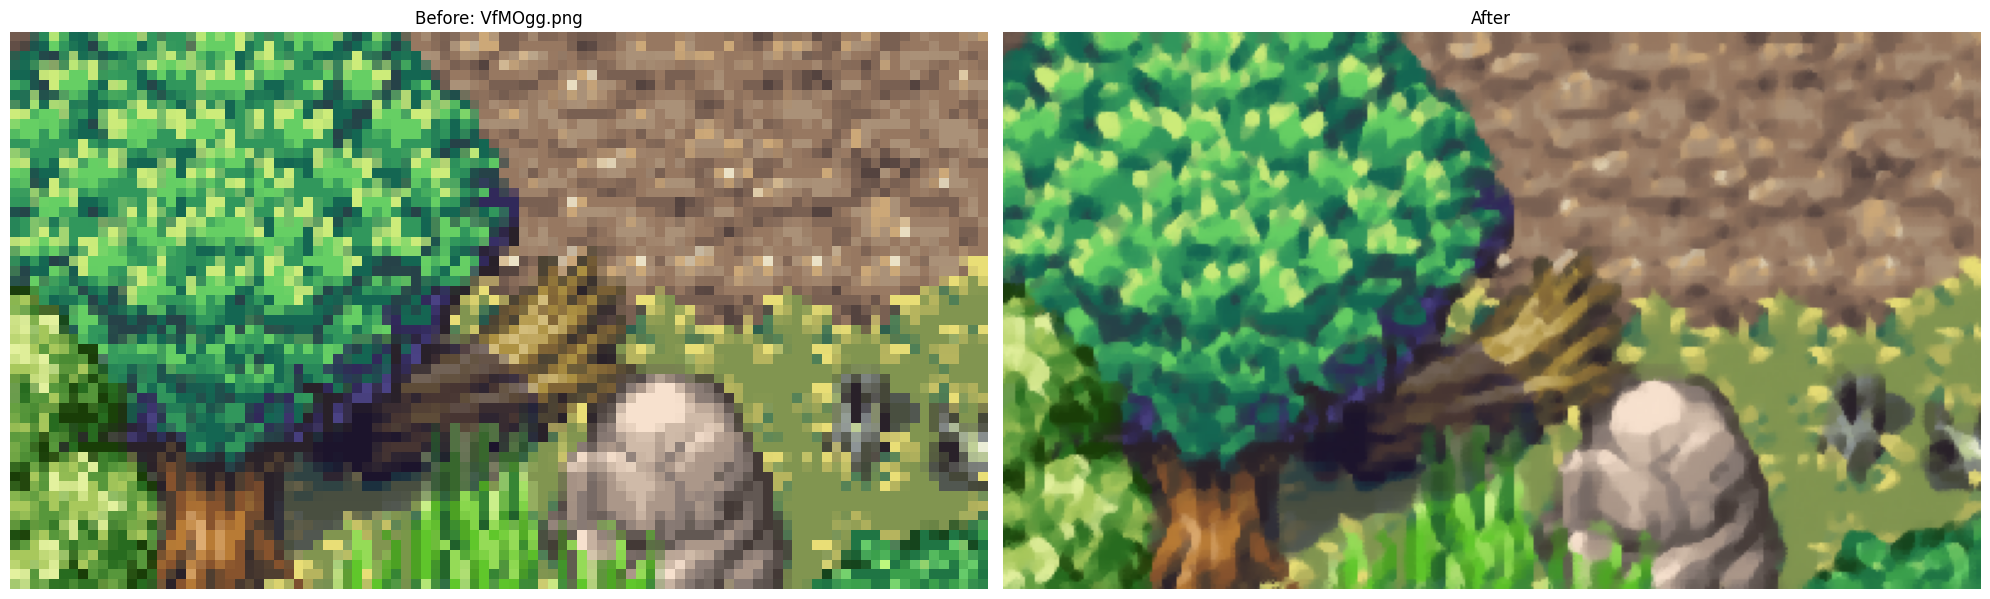

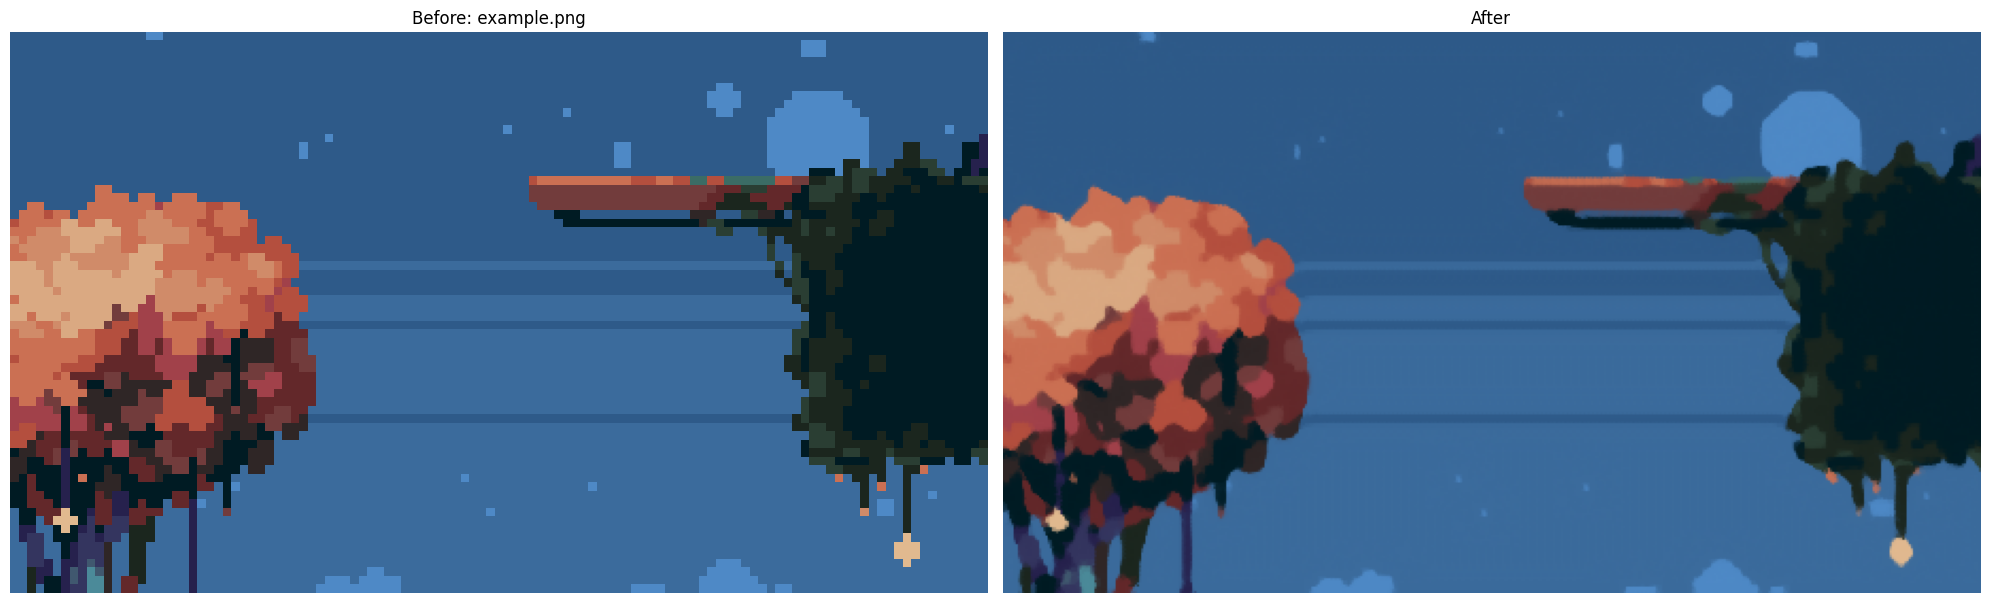

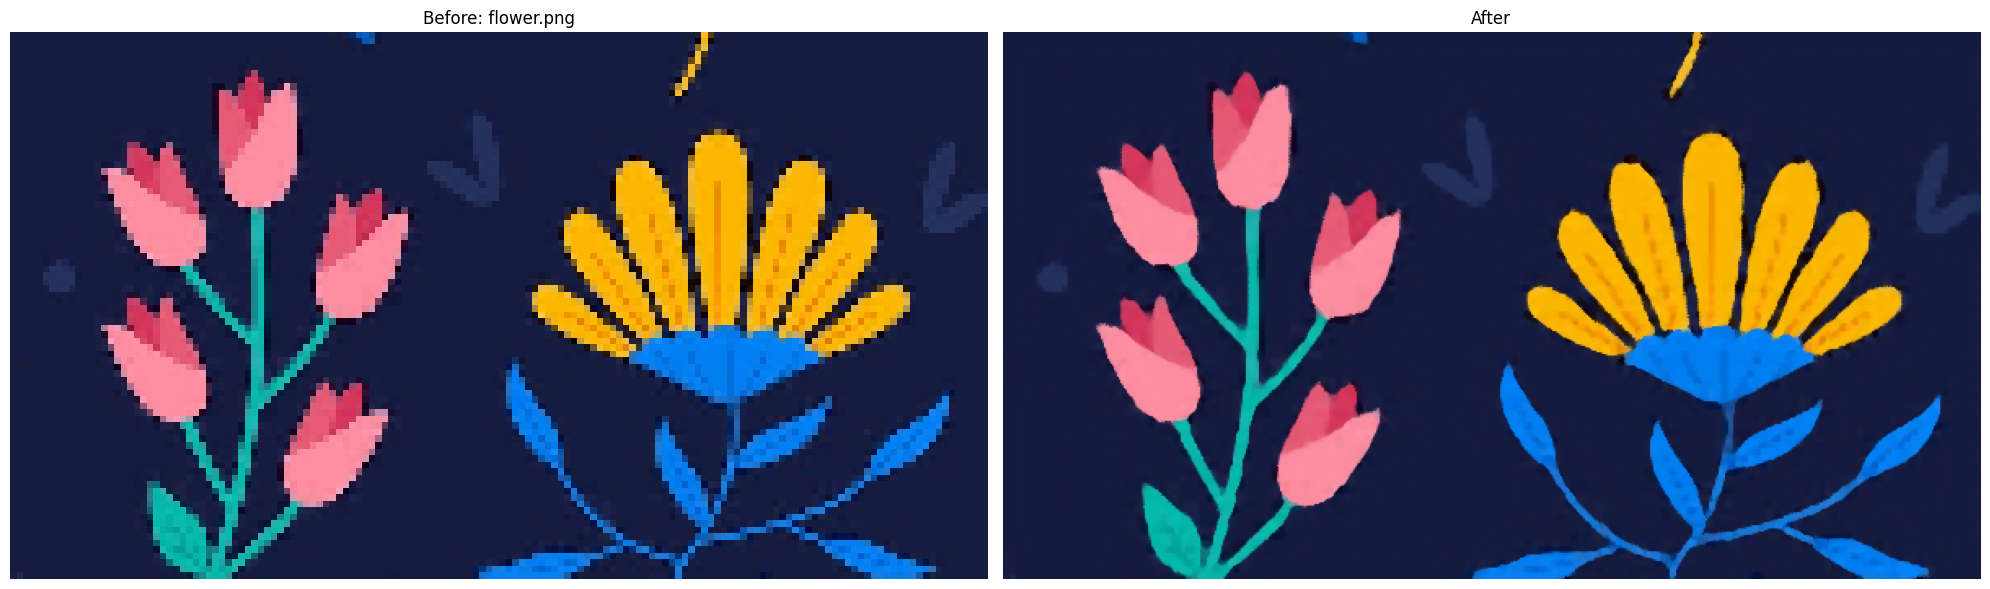

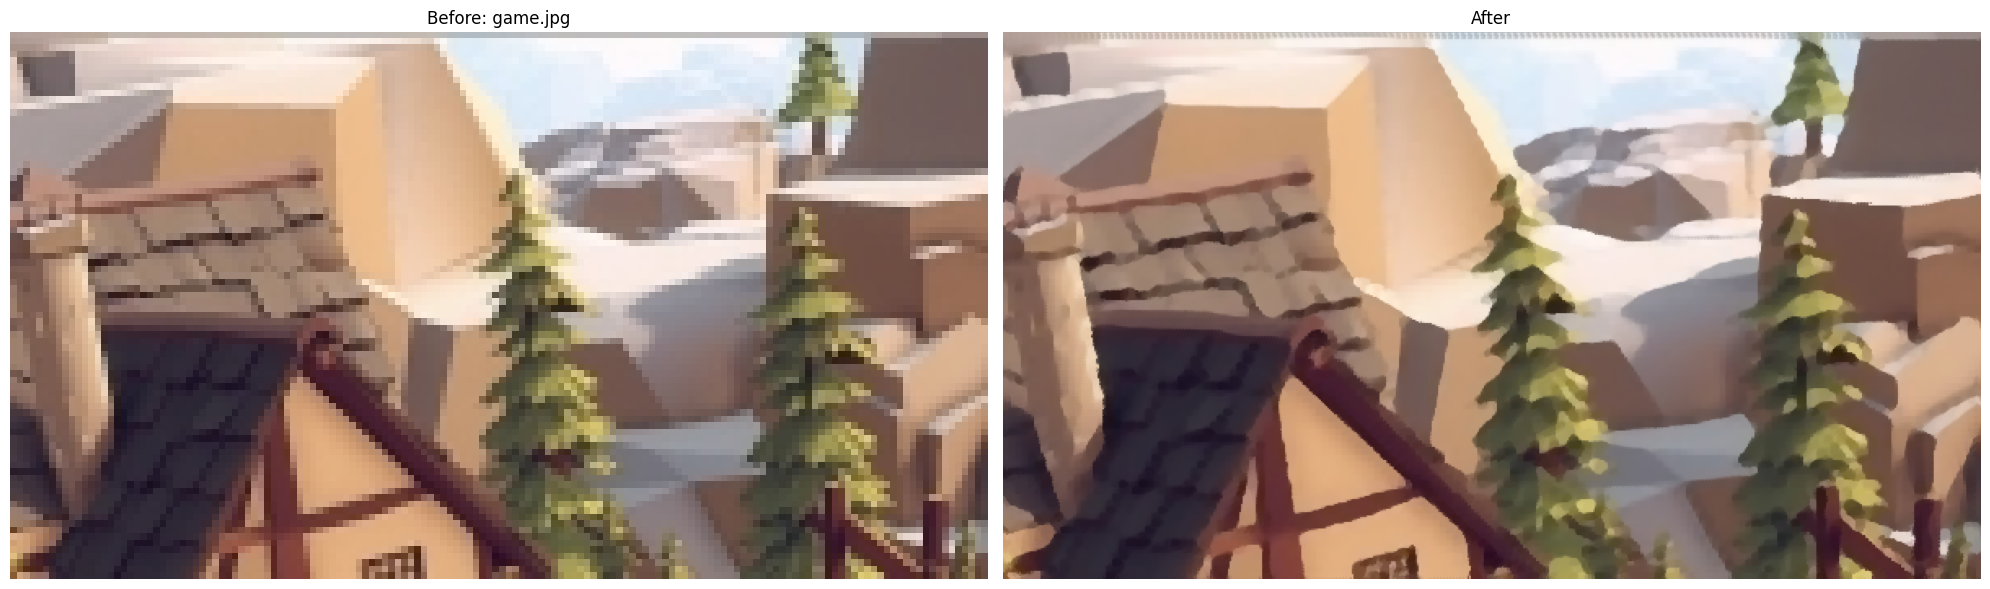

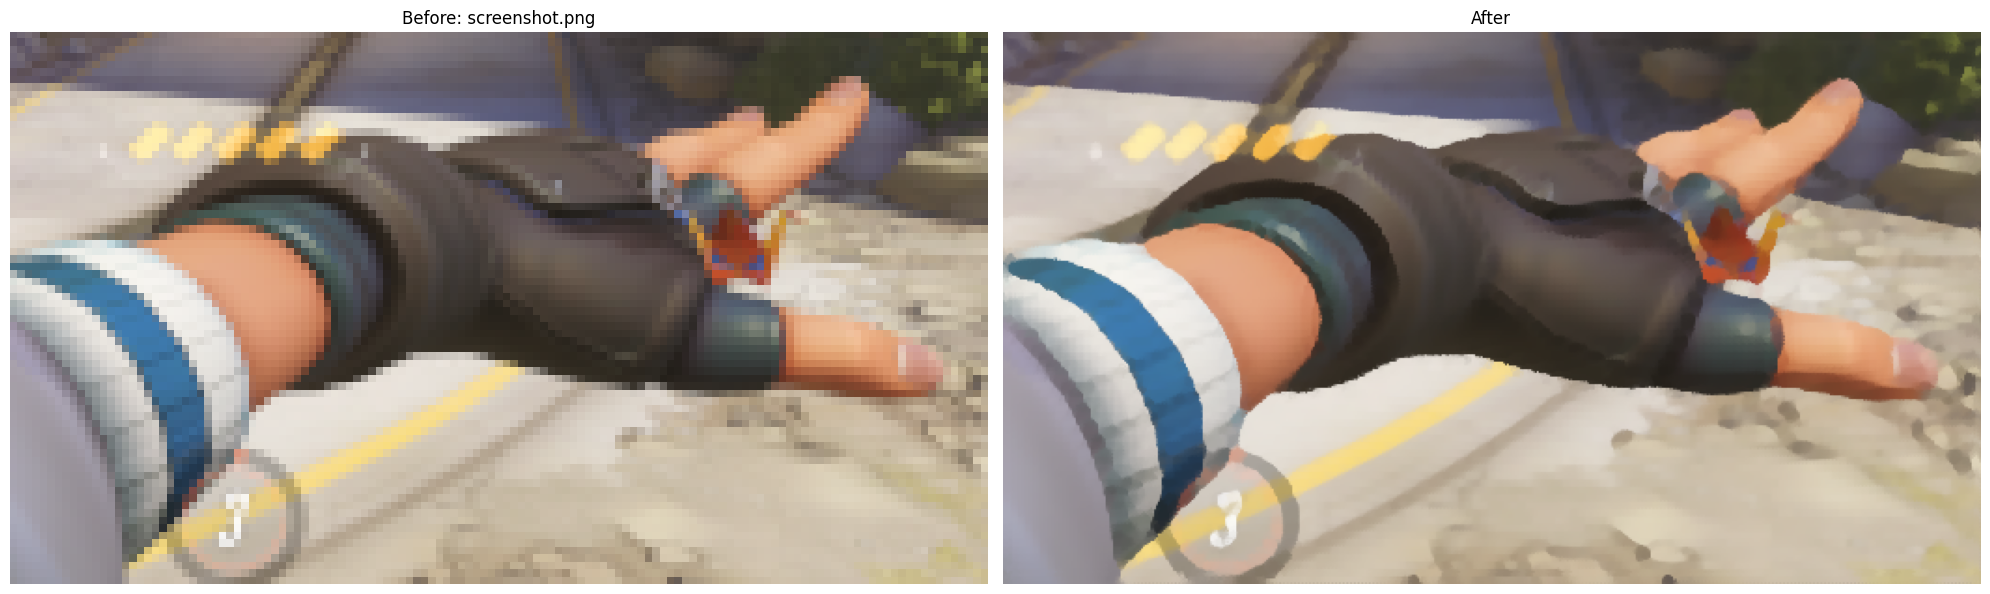

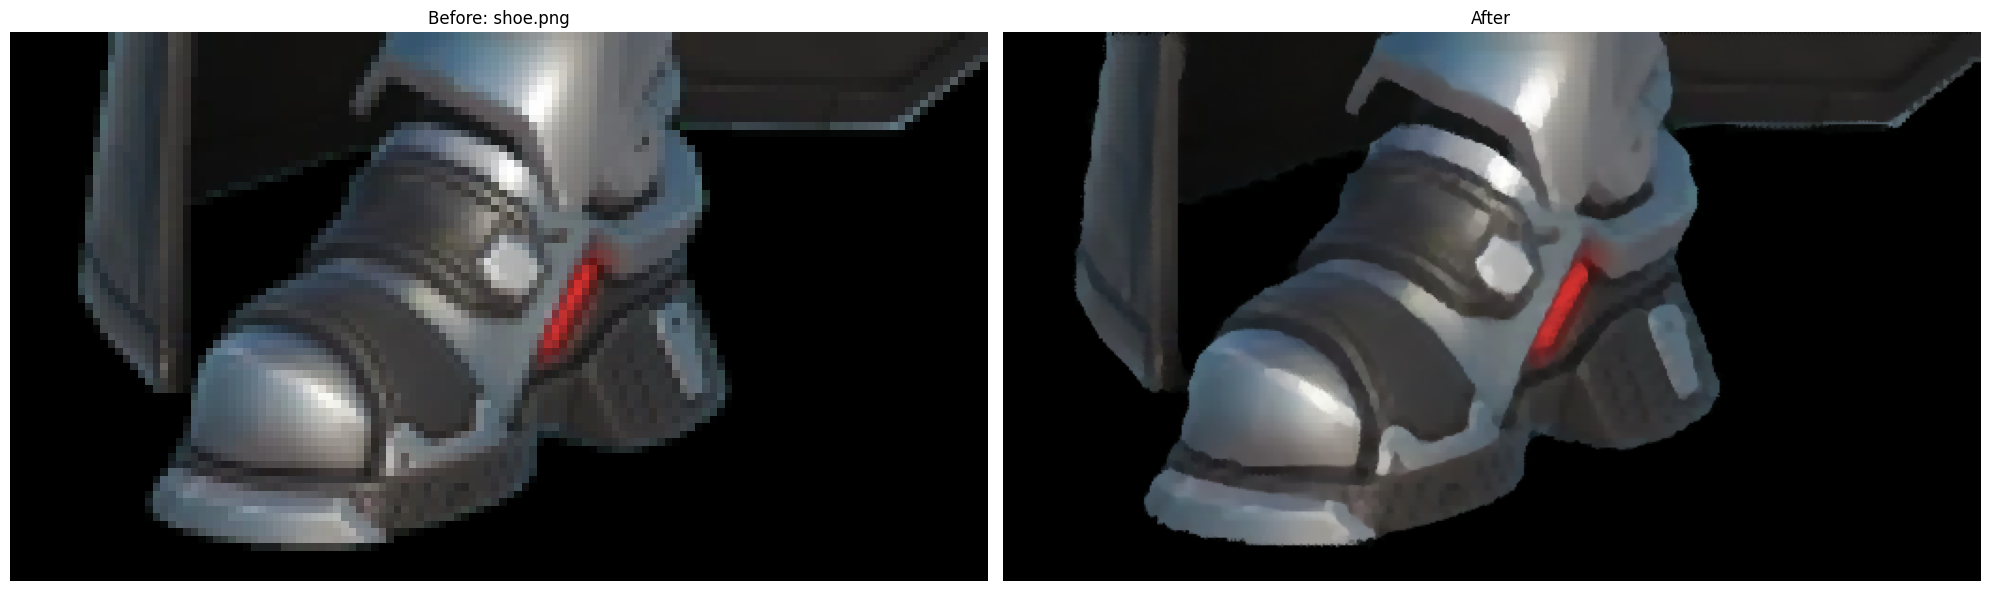

In [35]:
input_dir = Path("./test_images")
to_tensor = transforms.ToTensor()
to_pil = transforms.ToPILImage()

for p in sorted(input_dir.glob("*")):
    img = Image.open(p).convert("RGB")

    x = to_tensor(img).unsqueeze(0)

    with torch.no_grad():
        y = loaded_model(loaded_model(x)).clamp(0, 1)

    fig, ax = plt.subplots(1, 2, figsize=(20, 10))
    ax[0].imshow(img)
    ax[0].set_title(f"Before: {p.name}")
    ax[0].axis("off")

    ax[1].imshow(to_pil(y.squeeze(0)))
    ax[1].set_title("After")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()

Upscale and save your own image:

In [ ]:
# Load and prepare input image
img = Image.open("./your_image.png").convert("RGB")
transform = transforms.ToTensor()
x = transform(img).unsqueeze(0)

# Modify temperature before forward pass
loaded_model.temperature = 0.2  # Adjust the sharpness
with torch.no_grad():
    pred = loaded_model(loaded_model(x))  # Twice for 4x upscaling

# Save output
save_image(pred.clamp(0, 1), os.path.join("./", "upsampled.png"))